# Regression Assignment
Author: "Your Name Here"  

This assignment consists of 2 problem on Linear and Logistic Regression.

-   **Problem 1**: Linear Regression

## Notes:

-   **Writing Code.** You only need to write code in the cells marked `### YOUR CODE HERE (...) ###`. In the parentheses, we will be clear about what we expect you to print out from the cell.

-   **Writing Responses.** When answering the questions in this document, simply replace the "*Replace this text with your response"* with your answer. Keep the text in italics, as it makes grading easier. Do not change or delete any other text from this file. We are looking for short responses (no more than 2-3 sentences) that are precisely answer the question. For questions that have multiple sub-questions, you can answer each of the sub-questions in a sentence or two.

In [111]:
# Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(2025)

# Problem 1: Linear Regression for Predicting Housing Prices in Ames, Iowa

In this problem, we consider the Ames, Iowa Housing Prices dataset, which describes sales of 2,836 properties in the town of Ames, Iowa from 2006 to 2010. You will work with the dataset provided in the `AmesSales_modified.csv` file, which has been pre-processed to simplify the analysis. We started with a partially processed set available on [Github](https://github.com/mikearango/DATS_Final) and selected a few of the most relevant variables to include in our analysis. We also modified a few entries in the data.

The dataset contains 12 variables, described below. The first variable is the property's sale price---which we aim to predict. The other variables describe the property details in quantitative terms (square footage, number of rooms, date of construction...etc.). There is one categorical variable, BldgType, which describes different types of homes (e.g. townhouse, duplex, etc.).

-   **SalePrice**: the property's sale price (dollars)

-   **TotalRooms**: Total number of rooms

-   **Bedrooms**: Number of bedrooms

-   **FullBath**: Full bathrooms

-   **HalfBath**: Half baths

-   **LivArea**: Ground living area (sq. feet)

-   **Fireplaces**: Number of fireplaces

-   **GarageArea**: Size of garage (sq. feet)

-   **PoolArea**: Size of pool (sq. feet)

-   **YearBuilt**: Original construction date

-   **YearSold**: Year Sold

-   **BldgType**: Type of dwelling

Let's read in the dataset first to the variable `ames` and examine the first 6 rows of this dataset with the `head` function. Remember to save the data file `AmesSales_modified.csv` file is in the same folder as this notebook (`Assignment_1.ipynb`). If you are using Google Colab, make sure to upload `AmesSales_modified.csv` through the files tab on the left hand side.  

In [112]:
ames = pd.read_csv('AmesSales_modified.csv')
ames.head(6)

,SalePrice,TotalRooms,Bedrooms,FullBath,HalfBath,Fireplaces,LivArea,GarageArea,PoolArea,YearBuilt,YearSold,BldgType
0,215000.0,7,3,1,0,2,1656,528,0,1960,2010,1Fam
1,105000.0,5,2,1,0,0,896,730,0,1961,2010,1Fam
2,172000.0,6,3,1,1,0,1329,312,0,1958,2010,1Fam
3,244000.0,8,3,2,1,2,2110,522,0,1968,2010,1Fam
4,189900.0,6,3,2,1,1,1629,482,0,1997,2010,1Fam
5,195500.0,7,3,2,1,1,1604,470,0,1998,2010,1Fam


## (a): Visualizing SalePrice

Now, let's examine the distribution of the dependent variable `SalePrice`. Use the `describe()`and `hist()` functions to view summary statistics and distribution of `SalePrice`.

In [113]:
### YOUR CODE HERE (print summary statistics) ###

ames['SalePrice'].describe()


count      2836.000000
mean     178008.871650
std       70197.465489
min       62383.000000
25%      129837.500000
50%      160000.000000
75%      212000.000000
max      455000.000000
Name: SalePrice, dtype: float64

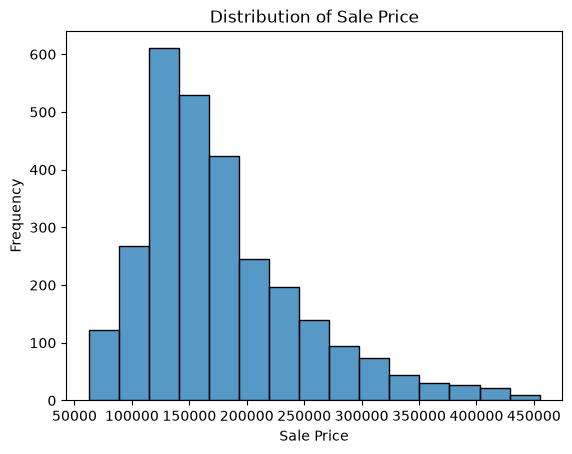

In [114]:
### YOUR CODE HERE (print the histogram) ###
sns.histplot(ames['SalePrice'], bins=15)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Price')
plt.show()

**Question 1**: What do you notice about the distribution of `SalePrice`? In Lecture 3 on medical cost prediction, we took the log of the dependent variable. Explain briefly why we do not need to take the log of `SalePrice` here.

***Answer 1:*** The distribution of `SalePrice` is right-skewed: most houses have lower prices, but there are some very high-priced properties pulling the mean upwards.

## (b): Train/Test Split

Let's train a linear regression model to predict `SalePrice`. But first, we will perform a test/train split by randomly dividing the dataset `ames` into 70% for training and 30% for testing. The following code creates the dataframes `train` and `test`.

In [115]:
# this part uses manual setting, but can we use sklearn here
train, test = train_test_split(ames, test_size=0.3, random_state=2025)
print("Training set dimensions:", train.shape)
print("Testing set dimensions:", test.shape)

Training set dimensions: (1985, 12)
Testing set dimensions: (851, 12)


The training set has 1985 rows and 12 columns.

**Question 2**: What is the purpose of setting `random_state = 2025`?

***Answer 2***: The purpose of `random_state = 2025` is to ensure reproducibility, in particular here for the random split between training and testing data. Without setting a seed, different runs of the script could result in different test/train splits, leading to inconsistent results.

## (c): Training a Linear Regression Model

Run the code below that defines a function which prints regression summary with significance stars. Unlike in R, `statsmodels` does not automatically print significance stars in Python.

In [116]:
# run this code cell
def significance_stars(p):
  if p < 0.001:
    return '***'
  elif p < 0.01:
    return '**'
  elif p < 0.05:
    return '*'
  elif p < 0.1:
    return '.'
  else:
    return ''

def print_summary_with_stars(model):
    # Get the full summary object
    summary = model.summary2()

    # Get coefficients table (table[1])
    coef_table = summary.tables[1].copy()

    # Add significance stars
    coef_table['Signif'] = coef_table['P>|t|'].apply(significance_stars)

    # Round only numeric columns to 4 decimal places
    numeric_columns = coef_table.select_dtypes(include=['float64', 'int64']).columns
    coef_table[numeric_columns] = coef_table[numeric_columns].round(4)

    # Print model info (from table[0])
    print("=" * 80)
    print("Regression Results")
    print("=" * 80)

    # Print basic model info
    info_table = summary.tables[0]
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"F-statistic: {model.fvalue:.4f}")
    print(f"Prob (F-statistic): {model.f_pvalue:.4f}")
    print(f"Log-Likelihood: {model.llf:.4f}")
    print(f"No. Observations: {int(model.nobs)}")
    print(f"Df Model: {int(model.df_model)}")
    print(f"Df Residuals: {int(model.df_resid)}")

    print("=" * 80)
    print("Coefficients:")
    print("-" * 80)
    print(coef_table.to_string(index=True))
    print("=" * 80)
    print("Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1")
    print("=" * 80)

Now, train a linear regression model on the `train` dataset to predict `SalePrice` using all other available variables as predictors. Assign the fitted model to the variable `model`. After training, evaluate the results by calling the custom function `print_summary_with_stars(model)`, which will display the regression output along with significance stars. Use this function consistently for summarizing all regression models throughout the assignment.


In [117]:
### YOUR CODE HERE (print the summary of model) ###

model = smf.ols('SalePrice ~ TotalRooms + Bedrooms + FullBath + HalfBath + LivArea + Fireplaces + GarageArea + PoolArea + YearBuilt + YearSold + BldgType', data=train).fit()
print_summary_with_stars(model)

Regression Results
R-squared: 0.7759
Adjusted R-squared: 0.7743
F-statistic: 487.0675
Prob (F-statistic): 0.0000
Log-Likelihood: -23452.3528
No. Observations: 1985
Df Model: 14
Df Residuals: 1970
Coefficients:
--------------------------------------------------------------------------------
                           Coef.      Std.Err.        t   P>|t|        [0.025        0.975] Signif
Intercept          -1.108831e+06  1.134790e+06  -0.9771  0.3286 -3.334345e+06  1.116683e+06       
BldgType[T.2fmCon] -8.862640e+03  4.933455e+03  -1.7964  0.0726 -1.853798e+04  8.126978e+02      .
BldgType[T.Duplex] -3.575831e+04  4.050621e+03  -8.8279  0.0000 -4.370226e+04 -2.781436e+04    ***
BldgType[T.Twnhs]  -3.004313e+04  4.395155e+03  -6.8355  0.0000 -3.866277e+04 -2.142349e+04    ***
BldgType[T.TwnhsE] -1.354779e+04  3.092865e+03  -4.3803  0.0000 -1.961342e+04 -7.482163e+03    ***
TotalRooms          2.838137e+03  9.652828e+02   2.9402  0.0033  9.450548e+02  4.731220e+03     **
Bedrooms        

**Question 3**: What is the in-sample (training) R2 of your model? Are there any variables which are not significant? What does it mean for a variable to not be significant?

***Answer 3:*** The in-sample (training) R² is 0.7759. Some variables, such as **FullBath, YearSold** are not statistically significant, meaning their p-values are greater than 0.05. This means that, after accounting for other variables in the model, there is insufficient statistical evidence to conclude that the variable has a meaningful effect on SalePrice. Mathematically, the p-value tests the null hypothesis 𝐻0:β𝑖=0
, where β𝑖
​ is the coefficient for the predictor variable. A large p-value suggests that we fail to reject 𝐻0
​, implying that the variable’s effect is indistinguishable from zero given the current data.

Note: Throughout this assignment, we will refer to the R2 on the training set as the training R2 or in-sample R2, while the R2 on the testing dataset is referred to as the testing R2 or out-of-sample R2.

**Question 4**: Please interpret the coefficient for `BldgTypeDuplex` in this linear regression model. What is the reference class? (Hint: Run `train['BldgType'].value_counts()`.)

***Answer 4***: The coefficient for BldgType[T.Duplex] in the regression model represents the **expected change in SalePrice** for duplex-style homes compared to the reference category.

From the `train['BldgType'].value_counts()` output, we see that the **most frequent category** is 1Fam (single-family homes), meaning that `BldgType1Fam` is the reference class. This means that all other BldgType categories, including Duplex, are compared against 1Fam.

The coefficient for `BldgTypeDuplex` indicates **how much the expected sale price changes when a house is a duplex instead of a single-family home**, holding all other variables constant. Here, the coefficient is negative: duplexes tend to sell for less than single-family homes.

In [118]:
train['BldgType'].value_counts()

BldgType
1Fam      1647
TwnhsE     150
Duplex      76
Twnhs       63
2fmCon      49
Name: count, dtype: int64

## (d): Analyzing the Residuals

Python offers a number of functional capabilities to help assess the quality of regression models and identify potential problems with the model. For linear regression models, you can access a significant amount of information by creating diagnostic plots. Here, `plot` does not mean plotting the regression line, rather it refers to a set of scatter-plot graphs of various objects like residuals of training data prediction values and the like.

Of particular interest to us is the graph of Fitted Value vs. Residual, which we can show by plotting the fitted values on the x-axis and the residuals on the y-axis. Run the following code where `model` is the name of your model from part (c).

Outlier indices: [1449, 1589, 1507]


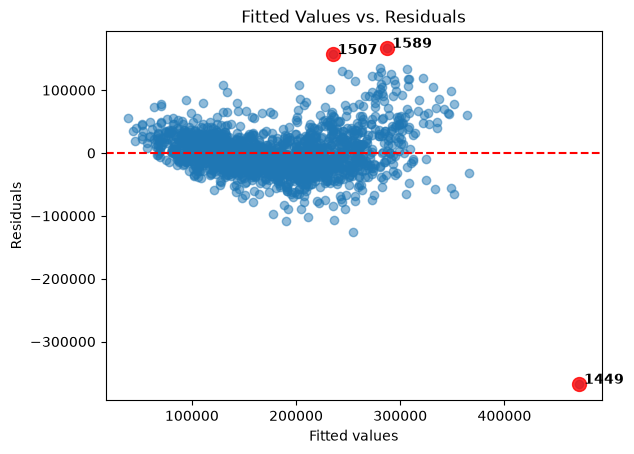

In [119]:
# Residuals vs Fitted plot
plt.scatter(model.fittedvalues, model.resid, alpha = 0.5)
plt.axhline(y = 0, color = 'red', linestyle = '--')

# Find outliers based on abs(residual)
abs_resid = np.abs(model.resid)
outlier_idx = abs_resid.nlargest(3).index
print("Outlier indices:", outlier_idx.tolist())

# Highlight outliers
plt.scatter(model.fittedvalues[outlier_idx], model.resid[outlier_idx],
           color='red', s=100, alpha=0.8, label='Outliers')
for idx in outlier_idx:
    plt.text(model.fittedvalues[idx], model.resid[idx],
             f' {idx}', fontsize=10, fontweight='bold')

plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Fitted Values vs. Residuals')
plt.show()

Here we will focus on identifying outliers. Outliers can sometimes have a disproportionate effect on the regression model and lead to poor estimates of the model coefficients. The plot above shows the residuals of the SalePrice regression model (vertical axis) and the “fitted values” which are the model’s predicted values on the training set (horizontal axis). In this plot, three extreme outliers are labeled: observations “1507”, “1589”, and “1449” (please email the teaching team if you do not see these 3 labels). These three outliers have very large negative or positive residuals, which means that the regression model does not fit these rows well (the predicted prices are significantly higher or lower than the actual prices).

Let's print these three observations and compare them to the rest of the training data, using the following commands.

In [120]:
outliers = [1449, 1589, 1507]
outlier_data = train.loc[outliers]
print("Outlier Observations:")
print(outlier_data)

Outlier Observations:
      SalePrice  TotalRooms  Bedrooms  FullBath  HalfBath  Fireplaces  \
1449   104700.0          11         5         3         1           2   
1589   455000.0           8         3         2         0           1   
1507   392500.0           5         2         2         0           1   

      LivArea  GarageArea  PoolArea  YearBuilt  YearSold BldgType  
1449     5104         624         0       1959      2008     1Fam  
1589     2042         724         0       2006      2007     1Fam  
1507     1652         482         0       2008      2008   TwnhsE  


Why are these 3 data points considered outliers? Let's examine some summary statistics for the `SalePrice` and `LivArea` using the `describe` command below.

In [121]:
train['SalePrice'].describe()

count      1985.000000
mean     176753.988917
std       69136.028219
min       62383.000000
25%      129200.000000
50%      160000.000000
75%      212000.000000
max      455000.000000
Name: SalePrice, dtype: float64

In [122]:
train['LivArea'].describe()

count    1985.000000
mean     1484.614106
std       469.108217
min       520.000000
25%      1124.000000
50%      1440.000000
75%      1730.000000
max      5104.000000
Name: LivArea, dtype: float64

**Question 5**: Explain intuitively why these 3 data points are considered outliers (i.e., why is their sale price unexpected). What are some potential explanations for why these 3 data points are in the dataset?

***Answer 5***: These 3 points are outliers because their SalePrice is much higher for sample 1589 and 1507. For sample 1449, the summary statistics show that this property has a large living area but were sold for much lower prices than the typical trend. Possible explanations include mistyped information, distressed sales, foreclosures, or major structural issues that significantly reduced their value.

## (e): Dealing with Outliers

When we find outliers that are also very influential in the model, we can consider the following options:

-   **Remove the observations from the model**. This is appropriate if we believe the outliers are due to data errors, or if the outliers are substantially different from the target population that we are trying to model (for example, we could probably justify excluding a professional athlete from a model that uses data on physical exercise habits).

-   **Treat the outlier values as missing data.** This should only be done if we believe the outlier values are due to data errors. Depending on the type of application, we may be able to use imputation or other methods to avoid discarding the entire observation from our dataset.

-   **Keep the outliers in our model**. If we do not believe that there is anything inherently wrong with the outlier, then it may reflect something important about the system we are trying to model.

In the setting of this model and this dataset, we will remove the outliers from our dataset. You can use this code to create a new training set (called `train2`) without the outliers.

In [123]:
train2 = train.drop(outlier_idx)
print("Training set2 dimensions:", train2.shape)

Training set2 dimensions: (1982, 12)


`train2` has 1982 rows (3 fewer than the 1985 that `train` had). This makes sense since we removed 3 rows.

Train a new linear regression model using `train2`. Name your model `model2`. Show a `summary` of `model2`.

In [124]:
### YOUR CODE HERE (print the summary of model2) ###

model2 = smf.ols('SalePrice ~ TotalRooms + Bedrooms + FullBath + HalfBath + LivArea + Fireplaces + GarageArea + PoolArea + YearBuilt + YearSold + BldgType', data=train2).fit()
print_summary_with_stars(model2)

Regression Results
R-squared: 0.7936
Adjusted R-squared: 0.7921
F-statistic: 540.0735
Prob (F-statistic): 0.0000
Log-Likelihood: -23323.2809
No. Observations: 1982
Df Model: 14
Df Residuals: 1967
Coefficients:
--------------------------------------------------------------------------------
                           Coef.      Std.Err.        t   P>|t|        [0.025       0.975] Signif
Intercept          -1.142447e+06  1.082502e+06  -1.0554  0.2914 -3.265417e+06  980524.2209       
BldgType[T.2fmCon] -9.303633e+03  4.705995e+03  -1.9770  0.0482 -1.853289e+04     -74.3722      *
BldgType[T.Duplex] -3.516735e+04  3.864169e+03  -9.1009  0.0000 -4.274564e+04  -27589.0511    ***
BldgType[T.Twnhs]  -2.986513e+04  4.192410e+03  -7.1236  0.0000 -3.808716e+04  -21643.0974    ***
BldgType[T.TwnhsE] -1.453032e+04  2.956300e+03  -4.9150  0.0000 -2.032813e+04   -8732.5105    ***
TotalRooms          1.675473e+03  9.267863e+02   1.8078  0.0708 -1.421132e+02    3493.0593      .
Bedrooms           -1.6

**Question 6**: What is the training (in-sample) R2 of your model (with outliers removed)? How does this compare to the model without removing outliers?

***Answer 6:*** The training R² of model2 (after removing outliers) is 0.7936, which is higher than the original model’s R². This suggests that removing extreme data points improved the model’s ability to fit the training data.

**Question 7**: Suppose a property developer in Iowa looks at your model (`model2`) and decides to encourage clients to add an extra fireplace because *a model developed at NC State shows that every additional fireplace constructed causes the value of a house to rise by more than \$10,000*. Is this claim supported by the model? Why or Why not?

***Answer 7:** The claim that “every additional fireplace increases home value by over $10,000” is not fully supported by our model. While the coefficient of Fireplaces might suggest an increase in SalePrice, this does not imply causality—other factors (e.g., home size, luxury features) may correlate with fireplaces.

**Question 8**: Are there any model coefficients that have the “wrong” (i.e., counter-intuitive) sign? Is there anything surprising to you about the statistical significance (or lack thereof) of certain coefficients? Check for correlations among the numerical variables in the training data and comment on how these correlations may explain these phenomena (code provided below).

***Answer 8:*** Several coefficients in the model have unexpected signs:


*   `Bedrooms` has a negative coefficient, meaning that, holding all else constant, adding an extra bedroom reduces SalePrice, which contradict intuition.
*   `FullBath` and `HalfBath` have negative coefficients as well, which is also counterintuitive.
*   `PoolArea` has a negative coefficient, suggesting that a larger pool area decreased SalePrice, which is unexpected.






In [125]:
# Correlation among numeric columns (excluding BldgType)
train2_numeric = train2.drop(columns=['BldgType'])
train2_numeric.corr()

,SalePrice,TotalRooms,Bedrooms,FullBath,HalfBath,Fireplaces,LivArea,GarageArea,PoolArea,YearBuilt,YearSold
SalePrice,1.000000,0.470041,0.143222,0.564286,0.272584,0.460989,0.700652,0.640596,0.012027,0.588034,-0.018303
TotalRooms,0.470041,1.000000,0.688877,0.511410,0.330668,0.268703,0.798216,0.277753,0.039384,0.092519,-0.042809
Bedrooms,0.143222,0.688877,1.000000,0.340357,0.248568,0.088516,0.550233,0.059398,0.013627,-0.067341,-0.021394
FullBath,0.564286,0.511410,0.340357,1.000000,0.141113,0.226688,0.629835,0.391698,-0.004393,0.463325,-0.006403
HalfBath,0.272584,0.330668,0.248568,0.141113,1.000000,0.203010,0.434307,0.164101,0.017360,0.261671,-0.008457
Fireplaces,0.460989,0.268703,0.088516,0.226688,0.203010,1.000000,0.418509,0.256273,0.030731,0.158956,-0.032577
LivArea,0.700652,0.798216,0.550233,0.629835,0.434307,0.418509,1.000000,0.438087,0.039092,0.223072,-0.015887
GarageArea,0.640596,0.277753,0.059398,0.391698,0.164101,0.256273,0.438087,1.000000,0.033973,0.468473,-0.011779
PoolArea,0.012027,0.039384,0.013627,-0.004393,0.017360,0.030731,0.039092,0.033973,1.000000,0.002468,-0.037996
YearBuilt,0.588034,0.092519,-0.067341,0.463325,0.261671,0.158956,0.223072,0.468473,0.002468,1.000000,-0.007254


1.   Bedrooms has a high correlation with TotalRooms (0.68) and LivArea (0.55). Since LivArea is a strong predictor of SalePrice, the separate effect of Bedrooms may be ambiguous. Larger houses typically have more bedrooms, but the additional bedrooms may indicate smaller room sizes per square foot, reducing their perceived value.
2.   FullBath and HalfBath are correlated with LivArea and TotalRooms, which are already strong predictors.
3.   PoolArea has a very low correlation with SalePrice, meaning it likely has a weak direct effect. The negative coefficient could arise due to the fact that some expensive homes without pools might dominate the dataset.

## (f): Out-of-Sample Performance

Let's calculate the out-of-sample R2 for `model` and `model2` on the testing data `test`. You can use the `predict` function to make predictions, and then calculate the `sse` and `sst` appropriately.

In [126]:
### YOUR CODE HERE (print OSR^2 for model) ###

test_predictions_model = model.predict(test)
y_test_actual = test['SalePrice']
y_train_actual = train['SalePrice']
sse = np.sum((y_test_actual - test_predictions_model) ** 2)
sst = np.sum((y_test_actual - np.mean(y_train_actual)) ** 2)
r2_model = 1 - (sse / sst)
print("Out-of-Sample R^2 for model:", r2_model)

Out-of-Sample R^2 for model: 0.7188934100046825


In [127]:
### YOUR CODE HERE (print OSR^2 for model2) ###

test_predictions_model2 = model2.predict(test)
y_train_actual = train2['SalePrice']
sse = np.sum((y_test_actual - test_predictions_model2) ** 2)
sst = np.sum((y_test_actual - np.mean(y_train_actual)) ** 2)
r2_model2 = 1 - (sse / sst)
print("Out-of-Sample R^2 for model2:", r2_model2)

Out-of-Sample R^2 for model2: 0.7183975047970169


**Question 9**: Compare the two OSR\^2 from `model` and `model2`. Do they align with your intuition? By removing outliers, is the out-of-sample R2 *guaranteed* to increase? Why or Why Not?

***Answer 9:*** The out-of-sample R² for model2 is 0.7184 while for model it is 0.7189. Removing outliers does not guarantee an increase in OSR²—sometimes removing data can make the model less generalizable if those outliers actually represent meaningful variations in the population.

## (g): A Simpler Model

Train one final linear regression model using only the 5 varaibles `BldgType`, `YearBuilt`, `Fireplaces`, `GarageArea`, `LivArea`. Call this model `model3`. Remember to train it on `train2` (outliers removed). Print out a `summary` of the model.

In [128]:
### YOUR CODE HERE (print the summary statistics of model3) ###

model3 = smf.ols('SalePrice ~ BldgType + YearBuilt + Fireplaces + GarageArea + LivArea', data=train2).fit()
print_summary_with_stars(model3)

Regression Results
R-squared: 0.7644
Adjusted R-squared: 0.7635
F-statistic: 800.2684
Prob (F-statistic): 0.0000
Log-Likelihood: -23454.1076
No. Observations: 1982
Df Model: 8
Df Residuals: 1973
Coefficients:
--------------------------------------------------------------------------------
                           Coef.    Std.Err.        t   P>|t|        [0.025        0.975] Signif
Intercept          -1.596604e+06  58063.8168 -27.4974  0.0000 -1.710477e+06 -1.482732e+06    ***
BldgType[T.2fmCon] -8.413580e+03   4966.2556  -1.6941  0.0904 -1.815324e+04  1.326077e+03      .
BldgType[T.Duplex] -4.072290e+04   3976.5580 -10.2407  0.0000 -4.852160e+04 -3.292421e+04    ***
BldgType[T.Twnhs]  -2.749398e+04   4383.7512  -6.2718  0.0000 -3.609125e+04 -1.889671e+04    ***
BldgType[T.TwnhsE] -3.967870e+03   2993.0983  -1.3257  0.1851 -9.837836e+03  1.902095e+03       
YearBuilt           8.275489e+02     30.0195  27.5671  0.0000  7.686757e+02  8.864221e+02    ***
Fireplaces          1.440461e+0

Calculate the out-of-sample R\^2 for `model3`.

In [129]:
### YOUR CODE HERE (print OSR^2 for model3) ###

test_predictions_model3 = model3.predict(test)
sse = np.sum((y_test_actual - test_predictions_model3) ** 2)
sst = np.sum((y_test_actual - np.mean(y_train_actual)) ** 2)
r2_model3 = 1 - (sse / sst)
print("Out-of-Sample R^2 for model3:", r2_model3)

Out-of-Sample R^2 for model3: 0.7100106258658783


**Question 11**: Discuss the pros and cons of `model3` (5 variables) versus `model2` (many variables). If you were an investor trying to flip homes in Ames, Iowa, which model would you use? Which model would you use to analyze the relationship between different features and SalePrice?

***Answer 11:*** The OSR² of model3 is 0.7100.

Pros of model3: Simpler, easier to interpret.

Cons of model3: Lower predictive power compared to model2.

If I were an investor flipping homes, I would prefer model2 because it has higher predictive power. However, if I wanted to analyze key relationships between features and SalePrice, I would use model3, as it is easier to interpret.


# Problem 2: Logistic Regression for the Framingham Heart Study

In [130]:
# Run this cell to import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [131]:
# Run this code cell
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars_log(model):
    """
    Print a comprehensive summary for GLM logistic regression models with significance stars
    """
    print("=" * 80)
    print("Logistic Regression Results")
    print("=" * 80)

    # Print basic model info for GLM
    print(f"Model Family: {model.family.__class__.__name__}")
    print(f"Link Function: {model.family.link.__class__.__name__}")
    print(f"Method: Maximum Likelihood Estimation (MLE)")
    print(f"Date: {model.summary().extra_txt}")
    print(f"No. Observations: {int(model.nobs)}")
    print(f"Df Model: {int(model.df_model)}")
    print(f"Df Residuals: {int(model.df_resid)}")

    print("-" * 40)
    print("Model Fit Statistics:")
    print(f"Log-Likelihood: {model.llf:.4f}")
    print(f"AIC: {model.aic:.4f}")
    print(f"BIC: {model.bic:.4f}")

    # For GLM, use pseudo R-squared instead of regular R-squared
    if hasattr(model, 'prsquared'):
        print(f"Pseudo R-squared (McFadden): {model.prsquared:.4f}")

    # Likelihood Ratio Test if available
    if hasattr(model, 'llr') and hasattr(model, 'llr_pvalue'):
        print(f"LLR p-value: {model.llr_pvalue:.4f}")

    print("=" * 80)
    print("Coefficients:")
    print("-" * 80)

    # Create coefficients table manually
    coef_data = {
        'Coef': model.params,
        'Std Err': model.bse,
        'z': model.tvalues,
        'P>|z|': model.pvalues,
        '[0.025': model.conf_int()[0],
        '0.975]': model.conf_int()[1]
    }

    coef_table = pd.DataFrame(coef_data)

    # Add significance stars
    coef_table['Signif'] = coef_table['P>|z|'].apply(significance_stars)

    # Round numeric columns to 4 decimal places
    numeric_columns = ['Coef', 'Std Err', 'z', 'P>|z|', '[0.025', '0.975]']
    for col in numeric_columns:
        coef_table[col] = coef_table[col].round(4)

    # Print the table
    print(coef_table.to_string())

    print("=" * 80)
    print("Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1")
    print("=" * 80)

Heart disease is the leading cause of death worldwide. About 15.5
million people died from coronary heart disease (CHD) in 2022—over 22%
of all deaths that year across the globe (including COVID).

In the late 1940s, the U.S. government started to take various
actions to address heart disease. As part of this effort, they decided
to track a large cohort of initially healthy people over time. The town
of Framingham, MA, was selected as the site for the study, which began
in 1948 with 5,209 participants. Participants were given a questionnaire
and a medical exam every two years, with data collected on physical and
behavioral characteristics. Over the years, the study has expanded to
include multiple generations and many factors, including genetic
information. This dataset is now famously known as the Framingham Heart
Study.

The dataset is contained in the file `framingham.csv` ,
with 3,658 observations corresponding to study participants. There are
16 variables in the dataset, described below. You aim to predict `tenYearCHD` , whether a patient experiences CHD within 10
years of their first examination. You will also aim to identify risk
factors to make recommendations for preventing CHD.


### Variables in the dataset `framingham.csv`

| Variable          | Description                                                                 |
|-------------------|-----------------------------------------------------------------------------|
| **male**          | Gender of patient (1 if male, 0 if female)                                  |
| **age**           | Age (in years) at first examination                                         |
| **education**     | Some high school, high school/GED, some college/vocational school, college  |
| **currentSmoker** | 1 if patient is a current smoker, 0 otherwise                               |
| **cigsPerDay**    | Number of cigarettes per day                                                |
| **BPMeds**        | 1 if patient is on blood pressure medication at time of first examination   |
| **prevalentStroke** | 1 if patient previously had a stroke, 0 otherwise                        |
| **prevalentHyp**  | 1 if patient is currently hypertensive, 0 otherwise                         |
| **diabetes**      | 1 if patient currently has diabetes, 0 otherwise                            |
| **totChol**       | Total cholesterol (mg/dL)                                                   |
| **sysBP**         | Systolic blood pressure                                                     |
| **diaBP**         | Diastolic blood pressure                                                    |
| **BMI**           | Body Mass Index: weight (kg)/height (m)^2                                   |
| **heartRate**     | Heart rate (beats/minute)                                                   |
| **glucose**       | Blood glucose level (mg/dL)                                                 |
| **tenYearCHD**    | 1 if patient has experienced coronary heart disease within 10 years, 0 otherwise |





Let’s first read in the necessary libraries and datasets.

In [132]:
data = pd.read_csv("framingham.csv")
data.head(6)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,College,0,0,0,0,0,0,195,106.0,70.0,26.97,80,77,0
1,0,46,High school/GED,0,0,0,0,0,0,250,121.0,81.0,28.73,95,76,0
2,1,48,Some high school,1,20,0,0,0,0,245,127.5,80.0,25.34,75,70,0
3,0,61,Some college/vocational school,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,1
4,0,46,Some college/vocational school,1,23,0,0,0,0,285,130.0,84.0,23.10,85,85,0
5,0,43,High school/GED,0,0,0,0,1,0,228,180.0,110.0,30.30,77,99,0


In [133]:
print(f"\nProportion of patients with CHD within 10 years: {data['TenYearCHD'].mean():.3f}")


Proportion of patients with CHD within 10 years: 0.152


The dataset is imbalanced: only 15% of patients experienced CHD
within 10 years. Let's create a train/test split with 75% in train and 25% in test.

In [134]:
X = data.drop('TenYearCHD', axis=1)
y = data['TenYearCHD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=25)
train=pd.concat([X_train, y_train], axis=1)
test=pd.concat([X_test, y_test], axis=1)
print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Train set size: 2743
Test set size: 915




## (a): Construct a logistic regression model

Using all the independent variables in the dataset, construct a
logistic regression model to predict the probability that a patient will
experience CHD within the next 10 years. Use the logistic regression (scikit‑learn) function with family='binomial'.

In [135]:
### YOUR CODE HERE ###

feature_names = X_train.columns.tolist()
model = smf.glm(f"TenYearCHD ~ {' + '.join(feature_names)}", data=train, family=sm.families.Binomial()).fit()
print_summary_with_stars_log(model)

Logistic Regression Results
Model Family: Binomial
Link Function: Logit
Method: Maximum Likelihood Estimation (MLE)
Date: None
No. Observations: 2743
Df Model: 17
Df Residuals: 2725
----------------------------------------
Model Fit Statistics:
Log-Likelihood: -1024.1073
AIC: 2084.2145
BIC: 2190.7171
Coefficients:
--------------------------------------------------------------------------------
                                               Coef  Std Err       z   P>|z|  [0.025  0.975] Signif
Intercept                                   -7.5864   0.8231 -9.2173  0.0000 -9.1996 -5.9733    ***
education[T.High school/GED]                -0.2371   0.2009 -1.1803  0.2379 -0.6308  0.1566       
education[T.Some college/vocational school] -0.2314   0.2246 -1.0303  0.3029 -0.6715  0.2088       
education[T.Some high school]               -0.0952   0.1845 -0.5161  0.6058 -0.4569  0.2665       
male                                         0.5320   0.1296  4.1035  0.0000  0.2779  0.7861    ***
age

***Question 1***: Suppose that a patient could choose
between (1) reducing their cigarettes per day (cigsPerDay) by 10 or reducing their systolic blood pressure sysBP by 10. According to the logistic regression model, which would lower that
patient’s risk of CHD more?  
***Answer 1***: cigPerDay



## (b): Prediction for the fourth patient

Consider patient number 4 in the original dataset who is a 61 year old male, current smoker, smokes 30 cigarettes per day…etc. Compute the model’s predicted probability that this individual will develop CHD in 10 years. Use the `predict()` function.

In [136]:
fourth_patient = data.iloc[3:4]
fourth_patient

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3,0,61,Some college/vocational school,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,1


In [137]:
### YOUR CODE HERE ###
fourth_patient.drop(columns="TenYearCHD")
prob_original = model.predict(fourth_patient)
prob_original

3    0.319657
dtype: float64

The fourth patient is recommended by his doctor to curtail his
smoking habits. Let’s calculate the predicted probability of CHD for a
patient with the same characteristics as patient four, but who smokes
only 20 cigarettes a day instead of 30? To do this in Python, we create a
copy of the 4th patient. Then, we update their cigsPerDay to 20. Then, run the same code as you did in the cell above on fourth_patient_copy .

In [138]:
### YOUR CODE HERE ###
fourth_patient_copy = fourth_patient.copy()
fourth_patient_copy['cigsPerDay'] = 20
fourth_patient_copy.drop(columns="TenYearCHD")
prob_copy = model.predict(fourth_patient_copy)
prob_copy

3    0.275499
dtype: float64



## (c): ROC and AUC

Generate probability predictions for all of the observations in the
test set using our logistic regression models. Plot the test set ROC,
and compute the AUC.

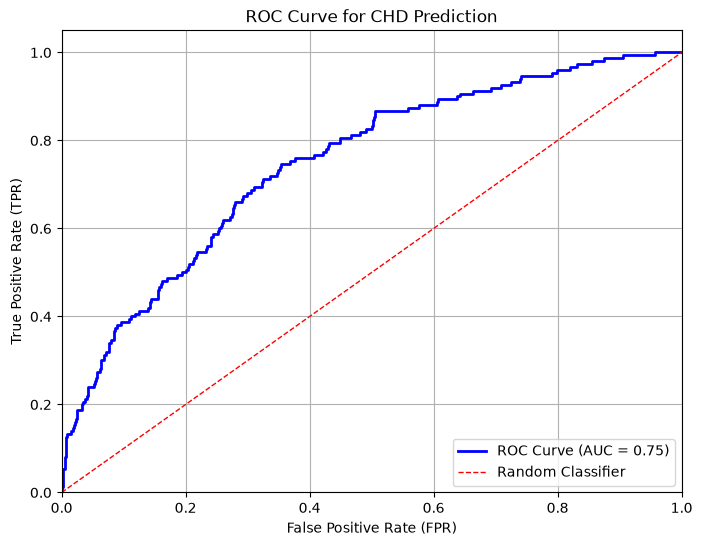

In [139]:
### YOUR CODE HERE ###

test_predictions = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, test_predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for CHD Prediction')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

***Question 2:*** Suppose I chose a probability threshold
of 0.25 for predicting that a patient will develop CHD in the next 10 years. The false positive rate of my predictions is 13.9%. What is my true positive rate? (approximately, from the AUC curve graph).  
***Answer 2:*** About 40%

---



***Question 3:*** If I were to decrease my threshold of predicting that a patient will develop CHD from 0.25 to 0.15, how would I expect the false positive rate and true positive rate to change? (Will it increase or decrease?)  
***Answer 3:*** By lowering threshold, we expect the model to predict that more patients will develop CHD, increasing the false positive rate. Therefore, the true positive rate will increase as well as seen on the ROC curve.



## (d) Prescribing Medication

To lower the risk of CHD, physicians can prescribe preventive
medication that lowers blood pressure or cholesterol. Recommending
preventive medications requires evidence-based analysis that weighs the
pros and cons of such interventions. A common methodology is known as
health economic evaluation, which accounts for medical costs and health
benefits (a monetized metric of improved life longevity).

Let us suppose that a colleague of yours has just completed a health economics study to assess a recently approved medication. The study has estimated that patients who experience CHD within the next 10 years are expected to incur a lifetime cost of \$150,000 associated with the disease—including the costs of treatment (\$75,000) and lower quality of life and life expectancy. The medicine is expected to lower patients’ risk of developing CHD within the next 10 years by a factor of 3. Regardless of whether a patient develops CHD, the preventive medication costs \$9,000 (per patient) over the next 10 years. A table describing the study’s analysis is shown in the table below, where p denotes the probability that a patient will develop CHD within the next 10 years without medication.

| Decision            | Outcome | Probability | Cost      |
|---------------------|---------|-------------|-----------|
| No medication       | CHD     | *p*         | \$150,000  |
| No medication       | No CHD  | 1 − *p*     | \$0        |
| Prescribe medication| CHD     | *p*/3       | \$159,000  |
| Prescribe medication| No CHD  | 1 − *p*/3   | \$9,000    |


***Question 4:*** What is the expected cost for a patient
who does not take the preventive medication, as a function of p? And what is the expected cost for a patient who is prescribed the preventive
medication, as a function of \(p\) ? For which values of \(p\) would you recommend the medication (considering cost alone)?  
***Answer 4:***

*   Does not take medication: p*150,000
*   Takes medication: p/3 * 159,000 + (1-p/3) * 9000  
Break even point is p=0.09.







## (e) Predicting Who to Prescribe Medication To

Let’s use the threshold \(p\) computed above to decide who to prescribe medication to. We decide to give the medication to patients with a predicted probability of CHD in 10 years higher than \(p\) . Recall from part (c) that we stored these predictions probabilities in a variable called `test_predictions`.

**Task.** Apply this threshold \(p\) to `test_predictions` and generate medication , which contains TRUE if a patient will be prescribed the medicine and FALSE otherwise. Then, print out a confusion numpy array / matrix, showing whether the patients we decide to treat will actually get CHD.

In [140]:
### YOUR CODE HERE ###

medication = test_predictions > 0.09
conf_matrix = confusion_matrix(y_test, medication)

# not expected of students, but easier for visualization
conf_df = pd.DataFrame(
    conf_matrix,
    index=["Actual: No CHD", "Actual: CHD"],
    columns=["Predicted: No CHD", "Predicted: CHD"]
)

print(conf_df)

                Predicted: No CHD  Predicted: CHD
Actual: No CHD                332             433
Actual: CHD                    19             131


Note that in this confusion numpy array / matrix, the rows indicate whether the patient actually got CHD, while the columns represent whether we decide to give them medication (i.e. if we predict CHD, we will give them medication).

***Question 5:*** From the confusion numpy array / matrix above, what is the accuracy, true positive rate and false positive rate of our medication decision? You can compute these using a calculator, or by running some simple computations in the Python console.

***Answer 5:*** See code below

In [141]:
tn, fp, fn, tp = conf_matrix.ravel()
accuracy = (tn + tp) / len(y_test)
tpr_med = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr_med = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"Accuracy: {accuracy:.3f}")
print(f"True Positive Rate: {tpr_med:.3f}")
print(f"False Positive Rate: {fpr_med:.3f}")

Accuracy: 0.506
True Positive Rate: 0.873
False Positive Rate: 0.566


***Question 6.*** Comment on the interpretation of false
positives and false negatives in our medication decision. As a medical practitioner deciding who to prescribe medicine to, which of these two quantities would you recommend to focus on minimizing?

***Answer 6:***

*   False positive: prescribed medication, but did not get CHD
*   False negative: did not prescribe medication but did get CHD

Any argument the student gives is fine.


---





From question 16, we see that the accuracy of our medical decisions is somewhat low. In fact, simply deciding to give no one the medication has an accuracy of about 84% (i.e., the proportion of people in our dataset who do not get CHD). However, our model achieved a pretty good AUC, showing that our model certainly has predictive power much higher than a model that randomly guesses.

***Question 7:*** Using this observation, comment briefly on whether AUC or accuracy is a better metric in imbalanced datasets.

***Answer 7:*** AUC is better metric in imbalanced datasets.



## (f) Economic Cost Comparison

Let’s consider two scenarios regarding the 914 patients in the test set. Assume that none of the 914 patients in the test were given the CHD medication, and `test[TenYearCHD]` is their CHD outcome in 10 years. From our data, we see that 140 out of 914 patients got CHD, leading to an economic cost of 140 * 150,000 =
21,000,000.

Let’s consider the following alternative scenarios.


1.   **Scenario 1:** Everyone in the test set is prescribed the medication. A patient who would have gotten CHD has a 2/3 chance of not getting CHD anymore, given the medication. A patient who would not have gotten CHD would obviously still not get CHD.
2.   **Scenario 2:** The patients with a probability of CHD higher than p is given the medication (as indicated by medication).



***Question 8.*** What is the total economic cost in Scenario 1?  
***Answer 8:*** The cost of giving everyone the medication is 9000*914. The cost from CHD is then 140/3 * 150,000 for a total cost of \$15,226,000.

***Question 9.*** What is the expected total economic cost in Scenario 2? By comparing this cost to that of scenario 1 and the \$22,976 per patient from doing nothing, comment on the value of our predictive medication model.  
***Answer 9:*** We prescribe the medication to 575
patients. The number of patients getting CHD is 18 + 122/3. The total cost is \$13,975,000 so we save about 1.25 million dollars from using the model.